In [ ]:
# MODELLO 1: modello con ricettori


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [53]:
# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
#lmbda = np.log(2) / T_half  # Costante di decadimento fisico (h^-1)
lmbda = 0.

# --- PARAMETRI CINETICI ---
# Costanti di velocita per l'interazione radiofarmaco-cellula
kon_eff = 0.04   # Costante apparente di associazione (h^-1) -> kon * R_tot
koff = 0.10      # Costante di dissociazione/stacco (h^-1)
kint = 0.12      # Costante di internalizzazione (h^-1)
kout = 0.01      # Costante di washout fuori dalla cellula (h^-1)

# --- PARAMETRI DELLA COLTURA ---
B_max = 8.0      # Attività massima legabile ai recettori di membrana (kBq)
A0 = 100.0       # Attività iniziale iniettata nel terreno di coltura (kBq)

In [54]:
def cellular_kinetic_system(t, y, lmbda, kon_eff, koff, kint, kout, B_max):
    """
    Sistema ODE per la cinetica del radiofarmaco in vitro.
    y = [Am, Ab, Aint]
    """
    Am, Ab, Aint, Adec = y
    
    # Frazione di recettori liberi disponibili: (1 - Ab / B_max)
    # Se Ab raggiunge B_max, il termine va a 0 (saturazione recettoriale)
    free_receptor_ratio = max(0.0, 1.0 - Ab / B_max)
    
    # Equazioni differenziali del sistema
    dAm_dt = -lmbda * Am - kon_eff * Am * free_receptor_ratio + koff * Ab
    dAb_dt = kon_eff * Am * free_receptor_ratio - (koff + kint + lmbda) * Ab + kout * Aint
    dAint_dt = kint * Ab - (kout + lmbda) * Aint
    dAdec_dt = lmbda * (Am + Ab + Aint)
    
    return [dAm_dt, dAb_dt, dAint_dt, dAdec_dt]

# Condizioni iniziali: tutta l'attivita e inizialmente nel terreno Am(0) = A0
y0 = [A0, 0.0, 0.0, 0.0]

# Intervallo temporale di simulazione (es. 72 ore)
t_span = (0, 1440)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, kon_eff, koff, kint, kout, B_max),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Aint, Adec = sol.y
A_cell_total = Ab + Aint  # Attività totale accumulata dalla cellula (membrana + internalizzata)
A_tot = Am + Ab + Aint + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq*h

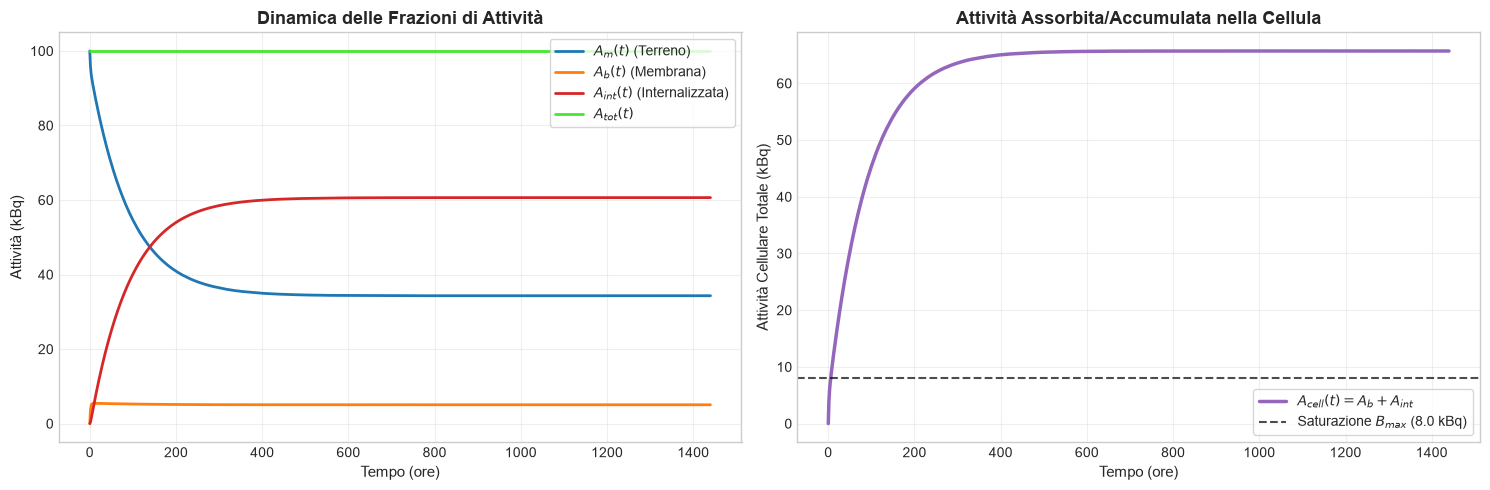

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-1440h): 89075.64 kBq·h
--------------------------------------------------


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei tre compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, Ab, label='$A_b(t)$ (Membrana)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, Aint, label='$A_{int}(t)$ (Internalizzata)', color='#d62728', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=2)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (kBq)', fontsize=11)
axes[0].set_title('Dinamica delle Frazioni di Attività', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Saturazione
axes[1].plot(t, A_cell_total, label='$A_{cell}(t) = A_b + A_{int}$', color='#9467bd', linewidth=2.5)
axes[1].axhline(y=B_max, color='black', linestyle='--', alpha=0.7, label=f'Saturazione $B_{{max}}$ ({B_max} kBq)')
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività Cellulare Totale (kBq)', fontsize=11)
axes[1].set_title('Attività Assorbita/Accumulata nella Cellula', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dell'attività cumulata
print(f"--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print(f"--------------------------------------------------")

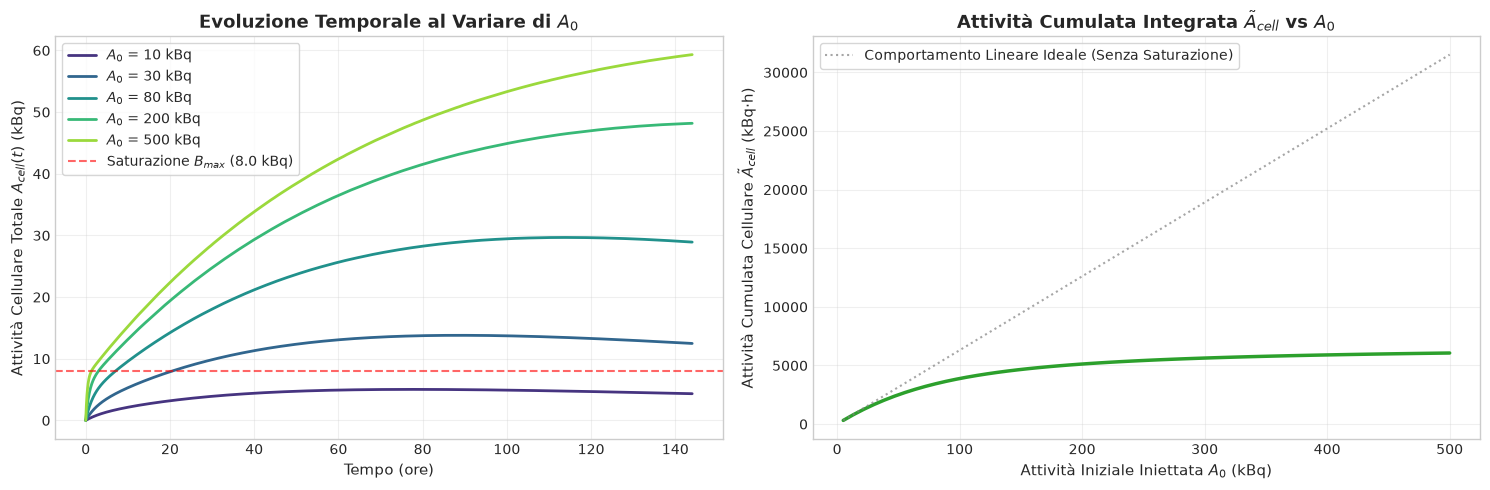

In [65]:
A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    # Risoluzione ODE per il generico A0_i
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, kon_eff, koff, kint, kout, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # Ab + Aint
    
    # Salviamo il picco massimo e l'attività cumulata integrata (proporzionale alla dose)
    max_A_cell_list.append(np.max(A_cell_i))
    cumulated_A_list.append(np.trapezoid(A_cell_i, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) per campioni significativi di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, kon_eff, koff, kint, kout, B_max),
        method='RK45'
    )
    A_cell_sample = sol_sample.y[1] + sol_sample.y[2]
    axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].axhline(y=B_max, color='red', linestyle='--', alpha=0.6, label=f'Saturazione $B_{{max}}$ ({B_max} kBq)')
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività Cellulare Totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione Temporale al Variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0 (Curva di Saturazione)
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività Cumulata Cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività Cumulata Integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Evidenziamo visivamente la deviazione dalla linearità
linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Comportamento Lineare Ideale (Senza Saturazione)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

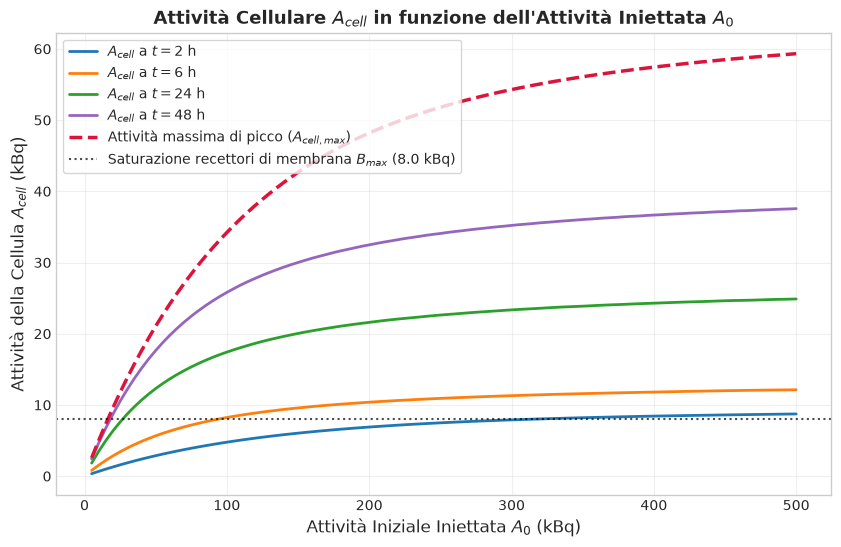

In [66]:
# --- PARAMETRIC SWEEP: A_cell vs A_0 ---
A0_range = np.linspace(5, 500, 100)  # Variazione continua dell'attività iniettata A0

# Tempi specifici a cui estrarre l'attività cellulare (in ore)
time_points = [2, 6, 24, 48]

# Dizionari e liste per raccogliere i dati
A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, kon_eff, koff, kint, kout, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # A_cell(t) = Ab(t) + Aint(t)
    
    # Estraggo A_cell ai tempi prefissati
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))  # Indice dell'istante t più vicino
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    # Estraggo il picco massimo assoluto di A_cell
    A_cell_max.append(np.max(A_cell_i))

# --- VISUALIZZAZIONE GRAFICA ---
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

# Curve di A_cell(A0) ai vari tempi
for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

# Curva del picco massimo A_cell_max(A0)
plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

# Limite teorico di saturazione di membrana
plt.axhline(y=B_max, color='black', linestyle=':', alpha=0.7, 
            label=f'Saturazione recettori di membrana $B_{{max}}$ ({B_max} kBq)')

# Formattazione grafico
plt.xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della Cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività Cellulare $A_{cell}$ in funzione dell\'Attività Iniettata $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

          RISULTATI DEL FIT SUI DATI REAL         
kon_eff (Associazione)   : 0.000546 ± 0.000407 h^-1
B_max   (Saturazione Mem): 0.087498 ± 1.088210 Bq/cellula
koff    (Dissociazione)  : 0.987608 ± 13.878392 h^-1
kint    (Internalizzazione): 2.436903 ± 54.165538 h^-1
kout    (Efflux/Riciclo) : 0.406506 ± 3.097335 h^-1
--------------------------------------------------
Chi-quadro Totale (Chi2) : 3.7602
Gradi di libertà (dof)   : 4
Chi-quadro Ridotto       : 0.9401


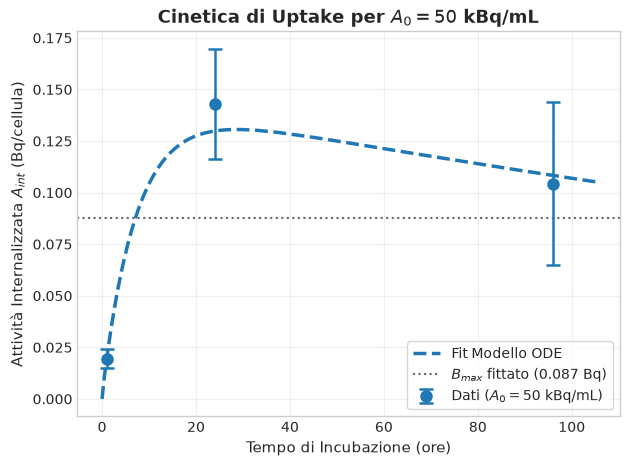

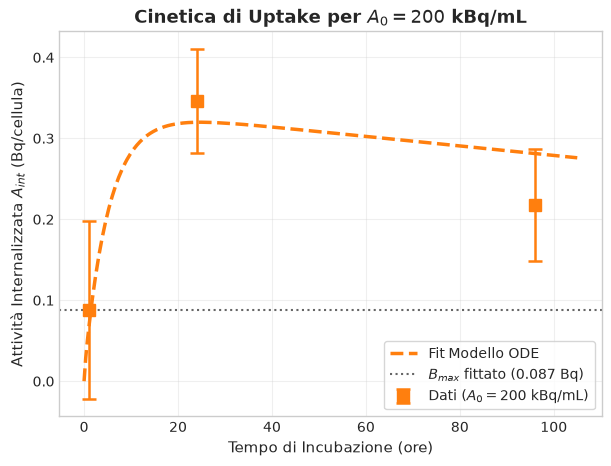

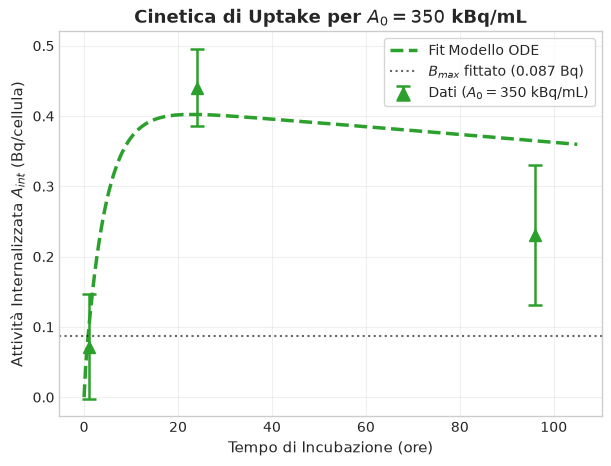

In [3]:
# =============================================================================
# 1. STRUTTURAZIONE DATI SPERIMENTALI
# =============================================================================
# Tempi di incubazione (ore)
t_exp = np.array([1.0, 24.0, 96.0])

# Attività iniettate A0 (kBq/mL)
A0_exp = np.array([50.0, 200.0, 350.0])

# Rumore di fondo misurato a A0 = 0 (Bq/cellula)
bg = np.array([0.004199309, 0.003368672, 0.000942459])

# Matrice Attività Cellulare Misurata A_int_raw (Bq/cellula)
# Righe: A0 (50, 200, 350 kBq/mL) | Colonne: Tempi (1h, 24h, 96h)
A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350
])

# Matrice delle Incertezze Sperimentali (err)
err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],  # A0 = 50
    [0.109901502, 0.064321945, 0.068945026],  # A0 = 200
    [0.074465535, 0.055049521, 0.099395703]   # A0 = 350
])

# Sottrazione del fondo per ottenere l'attività netta internalizzata
A_int_net = np.maximum(A_int_raw - bg, 1e-6)

# Parametro fisico: Emivita radionuclide in ore
# IMPO: Modifica T_half con l'emivita esatta del radionuclide usato nel tuo esperimento!
T_half = 7.4 * 24
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E RESIDUI PESATI (CHI-QUADRO)
# =============================================================================
def model_predictions(params, t_points, A0_values):
    """Risolve il sistema ODE per le varie concentrazioni A0."""
    kon_eff, B_max, koff, kint, kout = params
    
    def ode_system(t, y):
        Am, Ab, Aint = y
        free_rec = max(0.0, 1.0 - Ab / B_max)
        dAm = -lmbda * Am - kon_eff * Am * free_rec + koff * Ab
        dAb = kon_eff * Am * free_rec - (koff + kint + lmbda) * Ab + kout * Aint
        dAint = kint * Ab - (kout + lmbda) * Aint
        return [dAm, dAb, dAint]

    predictions = []
    t_span = (0, max(t_points))
    
    for A0 in A0_values:
        sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')
        predictions.append(sol.y[1]+sol.y[2])  # Estraiamo solo il compartimento internalizzato (Aint)
        
    return np.array(predictions)

def weighted_residuals(params, t_points, A0_values, data_matrix, weights_matrix):
    """Calcola i residui pesati con l'incertezza sperimentale: (Pred - Dati) / σ"""
    preds = model_predictions(params, t_points, A0_values)
    return ((preds - data_matrix) / weights_matrix).flatten()

# =============================================================================
# 3. CONDIZIONI INIZIALI, FIT E CALCOLO ERRORI
# =============================================================================
p0 = [0.005, 0.5, 0.1, 0.1, 0.01]

# Limiti sui parametri (Bounds)
lower_bounds = [1e-5,  0.001, 1e-4, 1e-4, 0.0]
upper_bounds = [0.5,   5.0,   5.0,  5.0,  1.0]

# Fit
res_fit = least_squares(
    weighted_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(t_exp, A0_exp, A_int_net, err_matrix),
    method='trf'
)

# Estrazione dei 5 parametri ottimizzati
kon_eff_f, B_max_f, koff_f, kint_f, kout_f = res_fit.x

# -----------------------------------------------------------------------------
# CALCOLO STIMA DEGLI ERRORI SUI PARAMETRI
# -----------------------------------------------------------------------------
N = A_int_net.size      # Numero totale di punti sperimentali (3 tempi x 3 conc = 9)
p = len(res_fit.x)      # Numero di parametri stimati (5)
dof = N - p             # Gradi di libertà (9 - 5 = 4)

# Somma dei quadrati dei residui pesati (Chi-quadro)
chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

# Calcolo della matrice di covarianza tramite la Jacobiana J
J = res_fit.jac
try:
    # Usiamo np.linalg.pinv (pseudo-inversa) per evitare errori se J^T J è quasi-singolare
    cov = np.linalg.pinv(J.T @ J)
    
    # Gli errori standard sono la radice della diagonale scalati con il Chi2 ridotto
    param_errors = np.sqrt(np.diagonal(cov) * chi2_red)
except Exception as e:
    param_errors = np.full(p, np.nan)
    print(f"Attenzione: Impossibile calcolare la covarianza ({e})")

# Unpacking degli errori
kon_err, B_max_err, koff_err, kint_err, kout_err = param_errors

# -----------------------------------------------------------------------------
# STAMPA RISULTATI CON INCERTEZZE
# -----------------------------------------------------------------------------
t_smooth = np.linspace(0, 105, 300)
preds_smooth = model_predictions(res_fit.x, t_smooth, A0_exp)

print("==================================================")
print("          RISULTATI DEL FIT SUI DATI REAL         ")
print("==================================================")
print(f"kon_eff (Associazione)   : {kon_eff_f:.6f} ± {kon_err:.6f} h^-1")
print(f"B_max   (Saturazione Mem): {B_max_f:.6f} ± {B_max_err:.6f} Bq/cellula")
print(f"koff    (Dissociazione)  : {koff_f:.6f} ± {koff_err:.6f} h^-1")
print(f"kint    (Internalizzazione): {kint_f:.6f} ± {kint_err:.6f} h^-1")
print(f"kout    (Efflux/Riciclo) : {kout_f:.6f} ± {kout_err:.6f} h^-1")
print("--------------------------------------------------")
print(f"Chi-quadro Totale (Chi2) : {chi2:.4f}")
print(f"Gradi di libertà (dof)   : {dof}")
print(f"Chi-quadro Ridotto       : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# GRAFICI
# =============================================================================

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blu, Arancione, Verde
markers = ['o', 's', '^']                   # Cerchio, Quadrato, Triangolo

for i, A0 in enumerate(A0_exp):
    plt.figure(figsize=(7, 5))
    
    # Dati sperimentali
    plt.errorbar(t_exp, A_int_net[i], yerr=err_matrix[i], 
                 fmt=markers[i], color=colors[i], ecolor=colors[i], elinewidth=1.8,
                 capsize=5, capthick=1.8, markersize=8, zorder=5,
                 label=f'Dati ($A_0 = {A0:.0f}$ kBq/mL)')
    
    # Curva di fit ODE
    plt.plot(t_smooth, preds_smooth[i], color=colors[i], linestyle='--', linewidth=2.5, 
             label='Fit Modello ODE')
    
    # Linea limite B_max
    plt.axhline(y=B_max_f, color='black', linestyle=':', alpha=0.6, 
                label=f'$B_{{max}}$ fittato ({B_max_f:.3f} Bq)')
    
    plt.title(f'Cinetica di Uptake per $A_0 = {A0:.0f}$ kBq/mL', fontsize=13, fontweight='bold')
    plt.xlabel('Tempo di Incubazione (ore)', fontsize=11)
    plt.ylabel('Attività Internalizzata $A_{int}$ (Bq/cellula)', fontsize=11)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Rimuovi il commento sottostante se desideri salvare i grafici come immagini PNG:
    # plt.savefig(f'uptake_fit_A0_{int(A0)}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_543738/850384976.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
/tmp/ipykernel_543738/850384976.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)


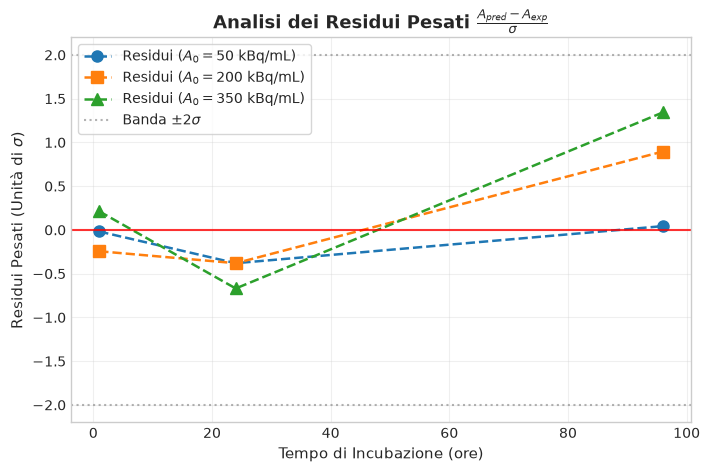

In [ ]:
# =============================================================================
# ANALISI DEI RESIDUI PESATI
# =============================================================================

# Calcolo delle predizioni e della matrice dei residui pesati (Pred - Dati) / sigma
preds_net = model_predictions(res_fit.x, t_exp, A0_exp)
residuals_matrix = (preds_net - A_int_net) / err_matrix

plt.figure(figsize=(8, 5))
for i, A0 in enumerate(A0_exp):
    plt.plot(t_exp, residuals_matrix[i], marker=markers[i], color=colors[i], 
             linestyle='--', linewidth=1.8, markersize=8,
             label=f'Residui ($A_0 = {A0:.0f}$ kBq/mL)')

# Linea di riferimento a 0 e bande a +- 2 sigma
plt.axhline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
plt.axhline(-2, color='gray', linestyle=':', alpha=0.6)

plt.title('Analisi dei Residui Pesati $\\frac{A_{pred} - A_{exp}}{\\sigma}$', fontsize=13, fontweight='bold')
plt.xlabel('Tempo di Incubazione (ore)', fontsize=11)
plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

         MATRICE DI CORRELAZIONE PARAMETRI        
Param        kon_eff     B_max      koff      kint      kout
------------------------------------------------------------
kon_eff        1.000    -0.019     0.035     0.024    -0.036
B_max         -0.019     1.000    -0.988    -0.957     0.989
koff           0.035    -0.988     1.000     0.964    -0.986
kint           0.024    -0.957     0.964     1.000    -0.919
kout          -0.036     0.989    -0.986    -0.919     1.000


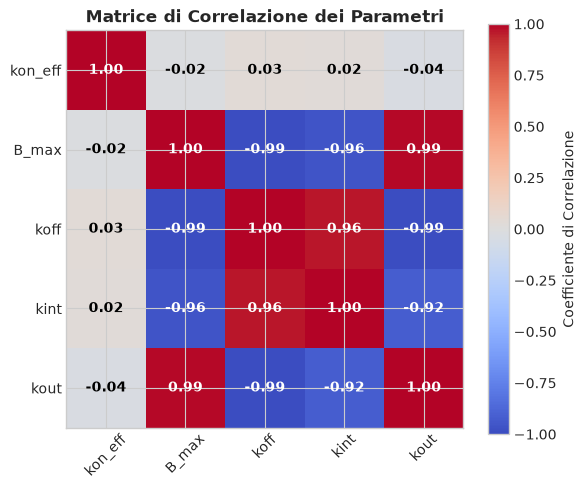

In [ ]:
# Derivazione della matrice di correlazione R_ij = Cov_ij / (sigma_i * sigma_j)
stds = np.sqrt(np.diagonal(cov))
corr_matrix = cov / np.outer(stds, stds)

param_names = ['kon_eff', 'B_max', 'koff', 'kint', 'kout']

# Stampa in console
print("==================================================")
print("         MATRICE DI CORRELAZIONE PARAMETRI        ")
print("==================================================")
header = f"{'Param':<10}" + "".join([f"{name:>10}" for name in param_names])
print(header)
print("-" * len(header))
for i, name in enumerate(param_names):
    row = f"{name:<10}" + "".join([f"{corr_matrix[i, j]:>10.3f}" for j in range(len(param_names))])
    print(row)
print("==================================================")

# Visualizzazione via Heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Coefficiente di Correlazione')
plt.xticks(range(len(param_names)), param_names, rotation=45)
plt.yticks(range(len(param_names)), param_names)
plt.title('Matrice di Correlazione dei Parametri', fontsize=12, fontweight='bold')

for i in range(len(param_names)):
    for j in range(len(param_names)):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr_matrix[i, j]) > 0.6 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CONFRONTO MODELLI AKAIKE INFORMATION CRITERION E BAYESIAN INFORMATION CRITERION (AIC / BIC) 
# =============================================================================
from scipy.optimize import least_squares

# Modello ridotto con kout = 0
def model_predictions_reduced(params_red, t_points, A0_values):
    kon_eff, kint, kout, koff = params_red
    B_max = 0.0  # Fissato a 0
    
    def ode_system(t, y):
        Am, Ab, Aint = y
        free_rec = max(0.0, 1.0 - Ab / B_max)
        dAm = -lmbda * Am - kon_eff * Am * free_rec + koff * Ab
        dAb = kon_eff * Am * free_rec - (koff + kint + lmbda) * Ab + kout * Aint
        dAint = kint * Ab - (kout + lmbda) * Aint
        return [dAm, dAb, dAint]

    predictions = []
    t_span = (0, max(t_points))
    for A0 in A0_values:
        sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')
        predictions.append(sol.y[2])
    return np.array(predictions)

def weighted_residuals_reduced(params_red, t_points, A0_values, data_matrix, weights_matrix):
    preds = model_predictions_reduced(params_red, t_points, A0_values)
    return ((preds - data_matrix) / weights_matrix).flatten()

# Fit del modello ridotto
p0_red = [0.005, 0.5, 0.1, 0.1]
bounds_red = ([1e-5, 0.001, 1e-4, 1e-4], [0.5, 5.0, 5.0, 5.0])
res_red = least_squares(
    weighted_residuals_reduced, p0_red, bounds=bounds_red,
    args=(t_exp, A0_exp, A_int_net, err_matrix), method='trf'
)

# Calcolo dei criteri AIC e BIC
N = A_int_net.size
k_full, k_red = len(res_fit.x), len(res_red.x)
chi2_full, chi2_red_mod = np.sum(res_fit.fun**2), np.sum(res_red.fun**2)

aic_full = N * np.log(chi2_full / N) + 2 * k_full
aic_red = N * np.log(chi2_red_mod / N) + 2 * k_red

bic_full = N * np.log(chi2_full / N) + k_full * np.log(N)
bic_red = N * np.log(chi2_red_mod / N) + k_red * np.log(N)

print("==================================================")
print("          CONFRONTO MODELLI (AIC / BIC)           ")
print("==================================================")
print(f"Modello Completo (5 param): Chi2 = {chi2_full:.4f} | AIC = {aic_full:.2f} | BIC = {bic_full:.2f}")
print(f"Modello Ridotto  (kout=0) : Chi2 = {chi2_red_mod:.4f} | AIC = {aic_red:.2f} | BIC = {bic_red:.2f}")
print("--------------------------------------------------")
delta_aic = aic_red - aic_full
print(f"Delta AIC (Ridotto - Completo): {delta_aic:.2f}")
if delta_aic > 2:
    print("-> Il Modello Completo (5 parametri) è NETTAMENTE PREFERIBILE.")
elif delta_aic < -2:
    print("-> Il Modello Ridotto (kout=0) è PREFERIBILE (più parsimonioso).")
else:
    print("-> I due modelli sono equivalenti dal punto di vista statistico.")
print("==================================================")

          CONFRONTO MODELLI (AIC / BIC)           
Modello Completo (5 param): Chi2 = 35.9798 | AIC = 20.47 | BIC = 21.26
Modello Ridotto  (kout=0) : Chi2 = 35.3326 | AIC = 20.31 | BIC = 21.10
--------------------------------------------------
Delta AIC (Ridotto - Completo): -0.16
-> I due modelli sono equivalenti dal punto di vista statistico.


In [ ]:
# =============================================================================
# CELLA 4: MONTE CARLO BOOTSTRAPPING (200 SIMULAZIONI)
# =============================================================================
n_iterations = 200
boot_params = []

np.random.seed(42)  # Riproducibilità

for _ in range(n_iterations):
    # Generazione dati sintetici distribuiti normalmente attorno ai dati medi
    synthetic_data = np.random.normal(loc=A_int_net, scale=err_matrix)
    synthetic_data = np.maximum(synthetic_data, 1e-6)
    
    # Refit
    res_boot = least_squares(
        weighted_residuals, p0, bounds=(lower_bounds, upper_bounds),
        args=(t_exp, A0_exp, synthetic_data, err_matrix), method='trf'
    )
    boot_params.append(res_boot.x)

boot_params = np.array(boot_params)

print("==================================================")
print("      ANALISI BOOTSTRAP MONTE CARLO (200 iter)    ")
print("==================================================")
param_names = ['kon_eff', 'B_max', 'koff', 'kint', 'kout']
for i, name in enumerate(param_names):
    mean_val = np.mean(boot_params[:, i])
    std_val = np.std(boot_params[:, i])
    ci_lower = np.percentile(boot_params[:, i], 2.5)
    ci_upper = np.percentile(boot_params[:, i], 97.5)
    print(f"{name:<10}: Media = {mean_val:.6f} | Std = {std_val:.6f} | IC 95% = [{ci_lower:.6f}, {ci_upper:.6f}]")
print("==================================================")

ValueError: not enough values to unpack (expected 5, got 4)

In [ ]:
# =============================================================================
# DOSIMETRIA
# =============================================================================
from scipy.integrate import trapezoid

# Griglia temporale estesa per integrare fino a decadimento radiativo completo (es. 500 ore)
t_dosimetry = np.linspace(0, 500, 1000)
preds_dosimetry = model_predictions(res_fit.x, t_dosimetry, A0_exp)

# Efficienza di Internalizzazione
eta = kint_f / (koff_f + kint_f) * 100

print("==================================================")
print("        METRICHE CINETICHE E DOSIMETRICHE         ")
print("==================================================")
print(f"Efficienza di Internalizzazione (eta) : {eta:.2f}%")
print("--------------------------------------------------")

for i, A0 in enumerate(A0_exp):
    curve = preds_dosimetry[i]
    # Attività cumulata (AUC) in Bq*h/cellula
    auc = trapezoid(curve, t_dosimetry)
    
    # Peak Uptake (t_max) e Valore massimo (A_max)
    idx_max = np.argmax(curve)
    t_max = t_dosimetry[idx_max]
    a_max = curve[idx_max]
    
    print(f"A0 = {A0:.0f} kBq/mL:")
    print(f"  - AUC (Attività Cumulata) : {auc:.4f} Bq·h/cellula")
    print(f"  - Peak Uptake (t_max)     : {t_max:.2f} ore (Max A_int: {a_max:.4f} Bq/cellula)")
print("==================================================")

        METRICHE CINETICHE E DOSIMETRICHE         
Efficienza di Internalizzazione (eta) : 19.23%
--------------------------------------------------
A0 = 50 kBq/mL:
  - AUC (Attività Cumulata) : 34.5208 Bq·h/cellula
  - Peak Uptake (t_max)     : 17.02 ore (Max A_int: 0.1347 Bq/cellula)
A0 = 200 kBq/mL:
  - AUC (Attività Cumulata) : 98.7816 Bq·h/cellula
  - Peak Uptake (t_max)     : 17.02 ore (Max A_int: 0.3244 Bq/cellula)
A0 = 350 kBq/mL:
  - AUC (Attività Cumulata) : 136.1776 Bq·h/cellula
  - Peak Uptake (t_max)     : 17.02 ore (Max A_int: 0.4058 Bq/cellula)


   RISULTATI FIT GLOBALE MULTI-CONCENTRAZIONE    
k0 (Dissociazione koff)       : 2.125973e+00 ± 9.815800e-01 h^-1
k1_eff (Associazione kon)     : 2.062708e-04 ± 5.304409e-05 h^-1
k2 (Internalizzazione kint)  : 2.768343e+00 ± 6.467447e-01 h^-1
k3 (Efflux/Riciclo kout)      : 4.970063e-01 ± 2.077554e-01 h^-1
B_max (Saturazione Membrana)  : 4.642051e-02 ± 3.420190e-03 Bq/cellula
--------------------------------------------------
Punti Sperimentali Totali (N) : 96
Chi-quadro Totale (Chi2)      : 206.1975
Gradi di libertà (dof)        : 91
Chi-quadro Ridotto            : 2.2659


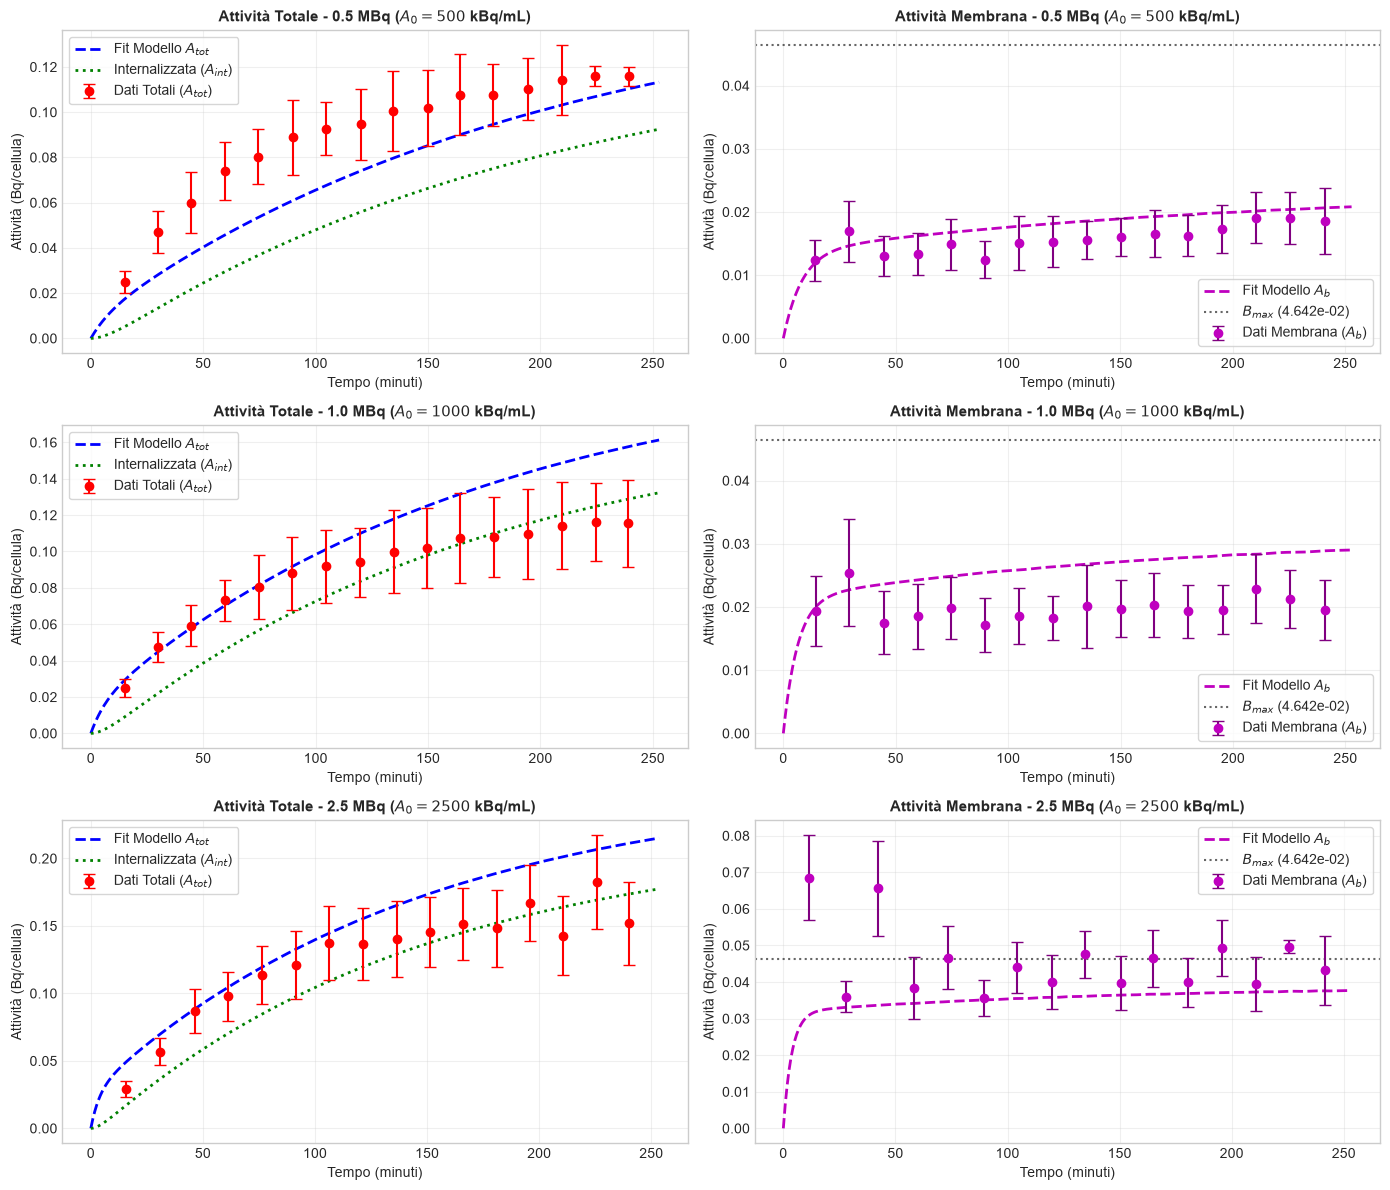

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# =============================================================================
# 1. CARICAMENTO DEI DATASET MULTI-CONCENTRAZIONE
# =============================================================================
# Struttura dati per le 3 concentrazioni (0.5 MBq, 1.0 MBq, 2.5 MBq)
dataset_info = [
    {
        'label': '0.5 MBq',
        'A0': 500.0,
        'tot_val': 'cell_activity_05MBq_values.csv',
        'tot_err': 'cell_activity_05MBq_errors.csv',
        'mem_val': 'membrane_activity_05MBq_values.csv',
        'mem_err': 'membrane_activity_05MBq_errors.csv'
    },
    {
        'label': '1.0 MBq',
        'A0': 1000.0,
        'tot_val': 'cell_activity_1MBq_values.csv',
        'tot_err': 'cell_activity_1MBq_errors.csv',
        'mem_val': 'membrane_activity_1MBq_values.csv',
        'mem_err': 'membrane_activity_1MBq_errors.csv'
    },
    {
        'label': '2.5 MBq',
        'A0': 2500.0,
        'tot_val': 'cell_activity_25MBq_values.csv',
        'tot_err': 'cell_activity_25MBq_errors.csv',
        'mem_val': 'membrane_activity_25MBq_values.csv',
        'mem_err': 'membrane_activity_25MBq_errors.csv'
    }
]

exp_data = []

for ds in dataset_info:
    # Caricamento Attività Totale
    df_tot_data = pd.read_csv(ds['tot_val'], header=None)
    df_tot_err  = pd.read_csv(ds['tot_err'], header=None)
    t_min_tot   = df_tot_data.iloc[:, 0].values
    y_tot_exp   = df_tot_data.iloc[:, 1].values
    err_tot     = np.maximum(np.abs(df_tot_err.iloc[:, 1].values - y_tot_exp), 1e-8)
    
    # Caricamento Attività Membrana
    df_mem_data = pd.read_csv(ds['mem_val'], header=None)
    df_mem_err  = pd.read_csv(ds['mem_err'], header=None)
    t_min_mem   = df_mem_data.iloc[:, 0].values
    y_mem_exp   = df_mem_data.iloc[:, 1].values
    err_mem     = np.maximum(np.abs(df_mem_err.iloc[:, 1].values - y_mem_exp), 1e-8)
    
    exp_data.append({
        'label': ds['label'],
        'A0': ds['A0'],
        't_min_tot': t_min_tot, 't_exp_tot': t_min_tot / 60.0, 'y_tot_exp': y_tot_exp, 'err_tot': err_tot,
        't_min_mem': t_min_mem, 't_exp_mem': t_min_mem / 60.0, 'y_mem_exp': y_mem_exp, 'err_mem': err_mem
    })

lmbda = 0.0  # Impostato a 0 per dati già decay-corrected

# =============================================================================
# 2. MODELLO ODE E CALCOLO RESIDUI GLOBALI
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """Risolve il sistema ODE per un dato A0 e restituisce (A_membrana, A_totale)."""
    k0, k1_eff, k2, k3, B_max = params

    def ode_system(t, y):
        Am, Ab, Aint = y
        free_rec = max(0.0, 1.0 - Ab / B_max) if B_max > 0 else 0.0

        dAm   = - lmbda * Am - k1_eff * Am * free_rec + k0 * Ab
        dAb   =   k1_eff * Am * free_rec - (k0 + k2 + lmbda) * Ab + k3 * Aint
        dAint =   k2 * Ab - (k3 + lmbda) * Aint
        return [dAm, dAb, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')

    A_mem_pred = sol.y[1]                 # A_b (Membrana)
    A_tot_pred = sol.y[1] + sol.y[2]      # A_b + A_int (Totale)
    return A_mem_pred, A_tot_pred

def global_residuals(params, datasets):
    """Calcola e concatena i residui pesati di tutti i dataset e concentrazioni."""
    all_residuals = []
    for exp in datasets:
        A0 = exp['A0']
        
        # Residui Totale
        _, pred_tot = solve_ode_system(params, exp['t_exp_tot'], A0)
        res_tot = (pred_tot - exp['y_tot_exp']) / exp['err_tot']
        
        # Residui Membrana
        pred_mem, _ = solve_ode_system(params, exp['t_exp_mem'], A0)
        res_mem = (pred_mem - exp['y_mem_exp']) / exp['err_mem']
        
        all_residuals.extend(res_tot)
        all_residuals.extend(res_mem)
        
    return np.array(all_residuals)

# =============================================================================
# 3. FIT GLOBALE MULTI-CONCENTRAZIONE
# =============================================================================
# Parametri: [k0, k1_eff, k2, k3, B_max]
p0           = [1.0,   5e-5,  0.5,  0.01, 0.1]
lower_bounds = [1e-4,  1e-8,  1e-5, 0.0,  1e-3]
upper_bounds = [5.0,   1e-2,  5.0,  2.0,  2.0]

res_fit = least_squares(
    global_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(exp_data,),
    method='trf'
)

# Estrazione parametri fittati
k0_f, k1_eff_f, k2_f, k3_f, B_max_f = res_fit.x

# Statistica del fit
N_tot_points = len(res_fit.fun)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

# Matrice di covarianza ed errori standard
J = res_fit.jac
try:
    cov = np.linalg.pinv(J.T @ J) * chi2_red
    param_errors = np.sqrt(np.diagonal(cov))
except Exception:
    param_errors = np.full(p_num, np.nan)

# =============================================================================
# 4. REPORT DEI RISULTATI
# =============================================================================
print("==================================================")
print("   RISULTATI FIT GLOBALE MULTI-CONCENTRAZIONE    ")
print("==================================================")
print(f"k0 (Dissociazione koff)       : {k0_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k1_eff (Associazione kon)     : {k1_eff_f:.6e} ± {param_errors[1]:.6e} h^-1")
print(f"k2 (Internalizzazione kint)  : {k2_f:.6e} ± {param_errors[2]:.6e} h^-1")
print(f"k3 (Efflux/Riciclo kout)      : {k3_f:.6e} ± {param_errors[3]:.6e} h^-1")
print(f"B_max (Saturazione Membrana)  : {B_max_f:.6e} ± {param_errors[4]:.6e} Bq/cellula")
print("--------------------------------------------------")
print(f"Punti Sperimentali Totali (N) : {N_tot_points}")
print(f"Chi-quadro Totale (Chi2)      : {chi2:.4f}")
print(f"Gradi di libertà (dof)        : {dof}")
print(f"Chi-quadro Ridotto            : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICI PER CIASCUNA CONCENTRAZIONE
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    t_max_eval = max(np.max(exp['t_exp_tot']), np.max(exp['t_exp_mem'])) * 1.05
    t_smooth_h = np.linspace(0, t_max_eval, 300)
    pred_mem_smooth, pred_tot_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0)
    pred_int_smooth = pred_tot_smooth - pred_mem_smooth
    t_smooth_min = t_smooth_h * 60.0

    # Colonna 1: Totale e Internalizzata
    ax_tot = axes[idx, 0]
    ax_tot.errorbar(exp['t_min_tot'], exp['y_tot_exp'], yerr=exp['err_tot'], 
                    fmt='ro', ecolor='red', capsize=4, label='Dati Totali ($A_{tot}$)', zorder=5)
    ax_tot.plot(t_smooth_min, pred_tot_smooth, 'b--', linewidth=2, label='Fit Modello $A_{tot}$')
    ax_tot.plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Internalizzata ($A_{int}$)')
    ax_tot.set_title(f"Attività Totale - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_tot.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_tot.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_tot.grid(True, alpha=0.3)
    ax_tot.legend(frameon=True)

    # Colonna 2: Membrana
    ax_mem = axes[idx, 1]
    ax_mem.errorbar(exp['t_min_mem'], exp['y_mem_exp'], yerr=exp['err_mem'], 
                    fmt='mo', ecolor='purple', capsize=4, label='Dati Membrana ($A_b$)', zorder=5)
    ax_mem.plot(t_smooth_min, pred_mem_smooth, 'm--', linewidth=2, label='Fit Modello $A_b$')
    ax_mem.axhline(y=B_max_f, color='black', linestyle=':', alpha=0.6, label=f'$B_{{max}}$ ({B_max_f:.3e})')
    ax_mem.set_title(f"Attività Membrana - {exp['label']} ($A_0 = {A0:.0f}$ kBq/mL)", fontsize=11, fontweight='bold')
    ax_mem.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_mem.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_mem.grid(True, alpha=0.3)
    ax_mem.legend(frameon=True)

plt.tight_layout()
plt.show()

In [69]:
# =============================================================================
# 6. ANALISI DEI RESIDUI PESATI (TOTALE + MEMBRANA)
# =============================================================================

# 1. Calcolo delle predizioni sui tempi sperimentali esatti
pred_mem_exp, _ = solve_ode_system(res_fit.x, t_exp_mem, A0_val)
_, pred_tot_exp = solve_ode_system(res_fit.x, t_exp_tot, A0_val)

# 2. Calcolo dei residui pesati in unità di sigma: (Pred - Dati) / sigma
residuals_tot_weighted = (pred_tot_exp - y_tot_exp) / err_tot
residuals_mem_weighted = (pred_mem_exp - y_mem_exp) / err_mem

# 3. Grafico dei Residui Pesati
plt.figure(figsize=(9, 5))

# Residui per l'Attività Totale
plt.plot(t_min_tot, residuals_tot_weighted, 'ro--', label='Residui Totale ($A_{tot}$)', 
         markersize=7, linewidth=1.8, zorder=4)

# Residui per l'Attività di Membrana
plt.plot(t_min_mem, residuals_mem_weighted, 'mo--', label='Residui Membrana ($A_b$)', 
         markersize=7, linewidth=1.8, zorder=4)

# Linea di riferimento a 0 e bande di confidenza a ± 2 sigma
plt.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
plt.axhline(2, color='gray', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')
plt.axhline(-2, color='gray', linestyle=':', alpha=0.7)

plt.title(r'Analisi dei Residui Pesati $\frac{A_{pred} - A_{exp}}{\sigma}$', fontsize=13, fontweight='bold')
plt.xlabel('Tempo (minuti)', fontsize=11)
plt.ylabel(r'Residui Pesati (Unità di $\sigma$)', fontsize=11)
plt.legend(frameon=True, fontsize=10, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Statistica sintetica della bontà dei residui
print("--------------------------------------------------")
print("          ANALISI STATISTICA DEI RESIDUI          ")
print("--------------------------------------------------")
print(f"Residui Totali    -> Media: {np.mean(residuals_tot_weighted):.3f} σ | Std: {np.std(residuals_tot_weighted):.3f} σ")
print(f"Residui Membrana  -> Media: {np.mean(residuals_mem_weighted):.3f} σ | Std: {np.std(residuals_mem_weighted):.3f} σ")
print("--------------------------------------------------")

<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel_19017/1534512931.py:26: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.axhline(2, color='gray', linestyle=':', alpha=0.7, label='Banda $\pm 2\sigma$')


ValueError: operands could not be broadcast together with shapes (16,) (15,) 

         MATRICE DI CORRELAZIONE PARAMETRI        
Param             k0    k1_eff        k2        k3     B_max
------------------------------------------------------------
k0             1.000     0.953    -0.291    -0.334     0.293
k1_eff         0.953     1.000    -0.297    -0.300     0.087
k2            -0.291    -0.297     1.000     0.961    -0.390
k3            -0.334    -0.300     0.961     1.000    -0.391
B_max          0.293     0.087    -0.390    -0.391     1.000


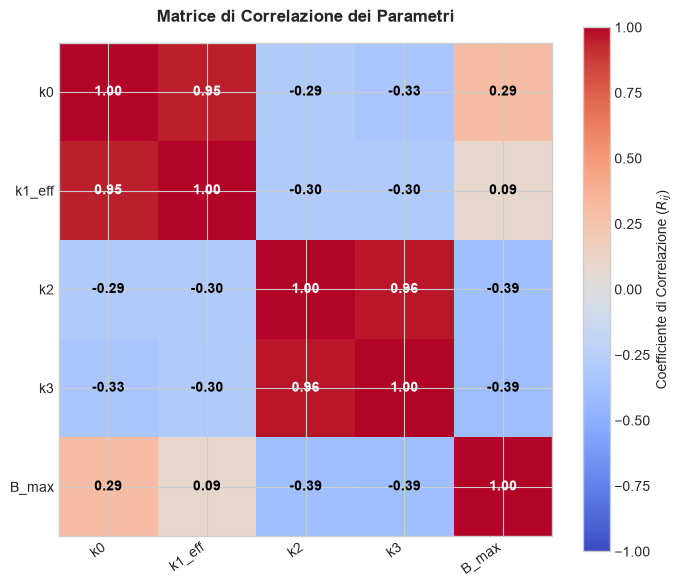

In [65]:
# =============================================================================
# 7. MATRICE DI CORRELAZIONE DEI PARAMETRI (R_ij = Cov_ij / (sigma_i * sigma_j))
# =============================================================================

# Nomi dei parametri secondo l'ordine di res_fit.x: [k0, k1_eff, k2, k3, B_max]
param_names = ['k0', 'k1_eff', 'k2', 'k3', 'B_max']

# Calcolo delle deviazioni standard e della matrice di correlazione
stds = np.sqrt(np.diagonal(cov))
# np.outer calcola il prodotto esterno (sigma_i * sigma_j)
corr_matrix = cov / np.outer(stds, stds)

# Sostituzione di eventuali NaN con 0 per evitare errori nel grafico
corr_matrix = np.nan_to_num(corr_matrix)

# -----------------------------------------------------------------------------
# Stampa in Console
# -----------------------------------------------------------------------------
print("==================================================")
print("         MATRICE DI CORRELAZIONE PARAMETRI        ")
print("==================================================")
header = f"{'Param':<10}" + "".join([f"{name:>10}" for name in param_names])
print(header)
print("-" * len(header))
for i, name in enumerate(param_names):
    row = f"{name:<10}" + "".join([f"{corr_matrix[i, j]:>10.3f}" for j in range(len(param_names))])
    print(row)
print("==================================================")

# -----------------------------------------------------------------------------
# Visualizzazione mediante Heatmap
# -----------------------------------------------------------------------------
plt.figure(figsize=(7, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Colorbar con etichetta
cbar = plt.colorbar(label='Coefficiente di Correlazione ($R_{ij}$)')
cbar.ax.tick_params(labelsize=10)

# Etichette degli assi
plt.xticks(range(len(param_names)), param_names, rotation=35, fontsize=10, ha='right')
plt.yticks(range(len(param_names)), param_names, fontsize=10)
plt.title('Matrice di Correlazione dei Parametri', fontsize=12, fontweight='bold', pad=15)

# Annotazione dei valori all'interno delle celle
for i in range(len(param_names)):
    for j in range(len(param_names)):
        val = corr_matrix[i, j]
        # Cambia colore del testo in base al contrasto dello sfondo
        text_color = 'white' if abs(val) > 0.55 else 'black'
        plt.text(j, i, f"{val:.2f}", ha='center', va='center',
                 color=text_color, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# 8. CONFRONTO MODELLI: AKAIKE E BAYESIAN INFORMATION CRITERION (AIC / BIC)
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Definizione e Fit del Modello Ridotto (k0 = 0)
# -----------------------------------------------------------------------------
def solve_ode_system_reduced(params_red, t_points, A0):
    """Risolve l'ODE del Modello Ridotto con k3 (kout) fissato a 0."""
    k1_eff, k2, k3, B_max = params_red
    k0 = 0.0  # Nessun efflux / riciclo

    def ode_system(t, y):
        Am, Ab, Aint = y
        free_rec = max(0.0, 1.0 - Ab / B_max) if B_max > 0 else 0.0
        lmbda = 0.

        dAm   = - lmbda * Am - k1_eff * Am * free_rec + k0 * Ab
        dAb   =   k1_eff * Am * free_rec - (k0 + k2 + lmbda) * Ab + k3 * Aint
        dAint =   k2 * Ab - (k3 + lmbda) * Aint
        return [dAm, dAb, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')

    A_mem_pred = sol.y[1]
    A_tot_pred = sol.y[1] + sol.y[2]
    return A_mem_pred, A_tot_pred

def simultaneous_residuals_reduced(params_red, t_tot, y_tot, e_tot, t_mem, y_mem, e_mem, A0):
    """Residui pesati per il modello ridotto."""
    _, pred_tot = solve_ode_system_reduced(params_red, t_tot, A0)
    res_tot = (pred_tot - y_tot) / e_tot

    pred_mem, _ = solve_ode_system_reduced(params_red, t_mem, A0)
    res_mem = (pred_mem - y_mem) / e_mem

    return np.concatenate([res_tot, res_mem])

# Fit del Modello Ridotto (4 parametri)
p0_red           = [1.0,   5e-5,  0.5,  0.1]
lower_bounds_red = [1e-4,  1e-8,  1e-5, 1e-3]
upper_bounds_red = [5.0,   1e-2,  5.0,  2.0]

res_red = least_squares(
    simultaneous_residuals_reduced, 
    p0_red, 
    bounds=(lower_bounds_red, upper_bounds_red),
    args=(t_exp_tot, y_tot_exp, err_tot, t_exp_mem, y_mem_exp, err_mem, A0_val),
    method='trf'
)

# -----------------------------------------------------------------------------
# 2. Calcolo Criteri AIC e BIC
# -----------------------------------------------------------------------------
N = len(y_tot_exp) + len(y_mem_exp)  # Numero totale di punti nei due dataset

k_full = len(res_fit.x)  # 5 parametri
k_red  = len(res_red.x)  # 4 parametri

chi2_full = np.sum(res_fit.fun**2)
chi2_red_mod = np.sum(res_red.fun**2)

# Formule AIC e BIC
aic_full = N * np.log(chi2_full / N) + 2 * k_full
aic_red  = N * np.log(chi2_red_mod / N) + 2 * k_red

bic_full = N * np.log(chi2_full / N) + k_full * np.log(N)
bic_red  = N * np.log(chi2_red_mod / N) + k_red * np.log(N)

delta_aic = aic_red - aic_full
delta_bic = bic_red - bic_full

# -----------------------------------------------------------------------------
# 3. Report dei Risultati
# -----------------------------------------------------------------------------
print("==================================================")
print("     CONFRONTO MODELLI STATISTICO (AIC / BIC)     ")
print("==================================================")
print(f"Punti Sperimentali Totali (N) : {N}")
print("--------------------------------------------------")
print(f"Modello Completo (5 param) : Chi2 = {chi2_full:.4f} | AIC = {aic_full:.2f} | BIC = {bic_full:.2f}")
print(f"Modello Ridotto  (k3=0)    : Chi2 = {chi2_red_mod:.4f} | AIC = {aic_red:.2f} | BIC = {bic_red:.2f}")
print("--------------------------------------------------")
print(f"Delta AIC (Ridotto - Completo) : {delta_aic:+.2f}")
print(f"Delta BIC (Ridotto - Completo) : {delta_bic:+.2f}")
print("--------------------------------------------------")

if delta_aic > 2:
    print("-> Il MODELLO COMPLETO (5 parametri) è NETTAMENTE PREFERIBILE.")
    print("   (La presenza del parametro k0 migliora significativamente il fit)")
elif delta_aic < -2:
    print("-> Il MODELLO RIDOTTO (k3=0) è PREFERIBILE.")
    print("   (Il parametro k0 non porta un beneficio giustificato dalla maggiore complessità)")
else:
    print("-> I due modelli sono SOSTANZIALMENTE EQUIVALENTI dal punto di vista statistico.")
print("==================================================")

     CONFRONTO MODELLI STATISTICO (AIC / BIC)     
Punti Sperimentali Totali (N) : 32
--------------------------------------------------
Modello Completo (5 param) : Chi2 = 122.5996 | AIC = 52.98 | BIC = 60.31
Modello Ridotto  (k3=0)    : Chi2 = 1687.9194 | AIC = 134.90 | BIC = 140.76
--------------------------------------------------
Delta AIC (Ridotto - Completo) : +81.91
Delta BIC (Ridotto - Completo) : +80.45
--------------------------------------------------
-> Il MODELLO COMPLETO (5 parametri) è NETTAMENTE PREFERIBILE.
   (La presenza del parametro k0 migliora significativamente il fit)


<>:220: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:220: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/kz/0cx5bgkd1lb9s2rncqvsctcr0000gn/T/ipykernel_19017/3784956910.py:220: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  ax_tot.set_title(f"Attività Totale - {exp['label']} (Fit Indipendente, $\chi^2_{{rid}}={res['chi2_red']:.2f}$)", fontsize=11, fontweight='bold')


                           RISULTATI FIT SINGOLI PER CONCENTRAZIONE                          
Parametro                | 0.5 MBq                      | 1.0 MBq                      | 2.5 MBq                     
---------------------------------------------------------------------------------------------
k0 (koff, h^-1)          | 1.0017e+00 ± 2.2850e+00 | 1.0000e-02 ± 7.9594e-01 | 2.1487e-01 ± 1.2467e+00
k1_eff (kon, h^-1)       | 2.1673e-04 ± 2.5016e-05 | 9.8873e-05 ± 9.4392e-06 | 4.5103e-05 ± 1.6522e-05
k2 (kint, h^-1)          | 9.9996e+00 ± 2.6810e+00 | 6.3246e+00 ± 1.0529e+00 | 3.4348e+00 ± 2.1128e+00
k3 (kout, h^-1)          | 1.3933e+00 ± 3.0178e-01 | 9.5802e-01 ± 1.8563e-01 | 1.0053e+00 ± 6.0422e-01
B_max (Bq/cell)          | 1.3530e-01 ± 4.2461e-02 | 1.1281e-01 ± 1.3955e-02 | 1.8853e-01 ± 9.2879e-02
k_ns (NSB coefficient)   | 5.1112e-06 ± 4.2926e-06 | 4.9138e-06 ± 2.5407e-06 | 4.2176e-06 ± 5.9008e-06
----------------------------------------------------------------------------

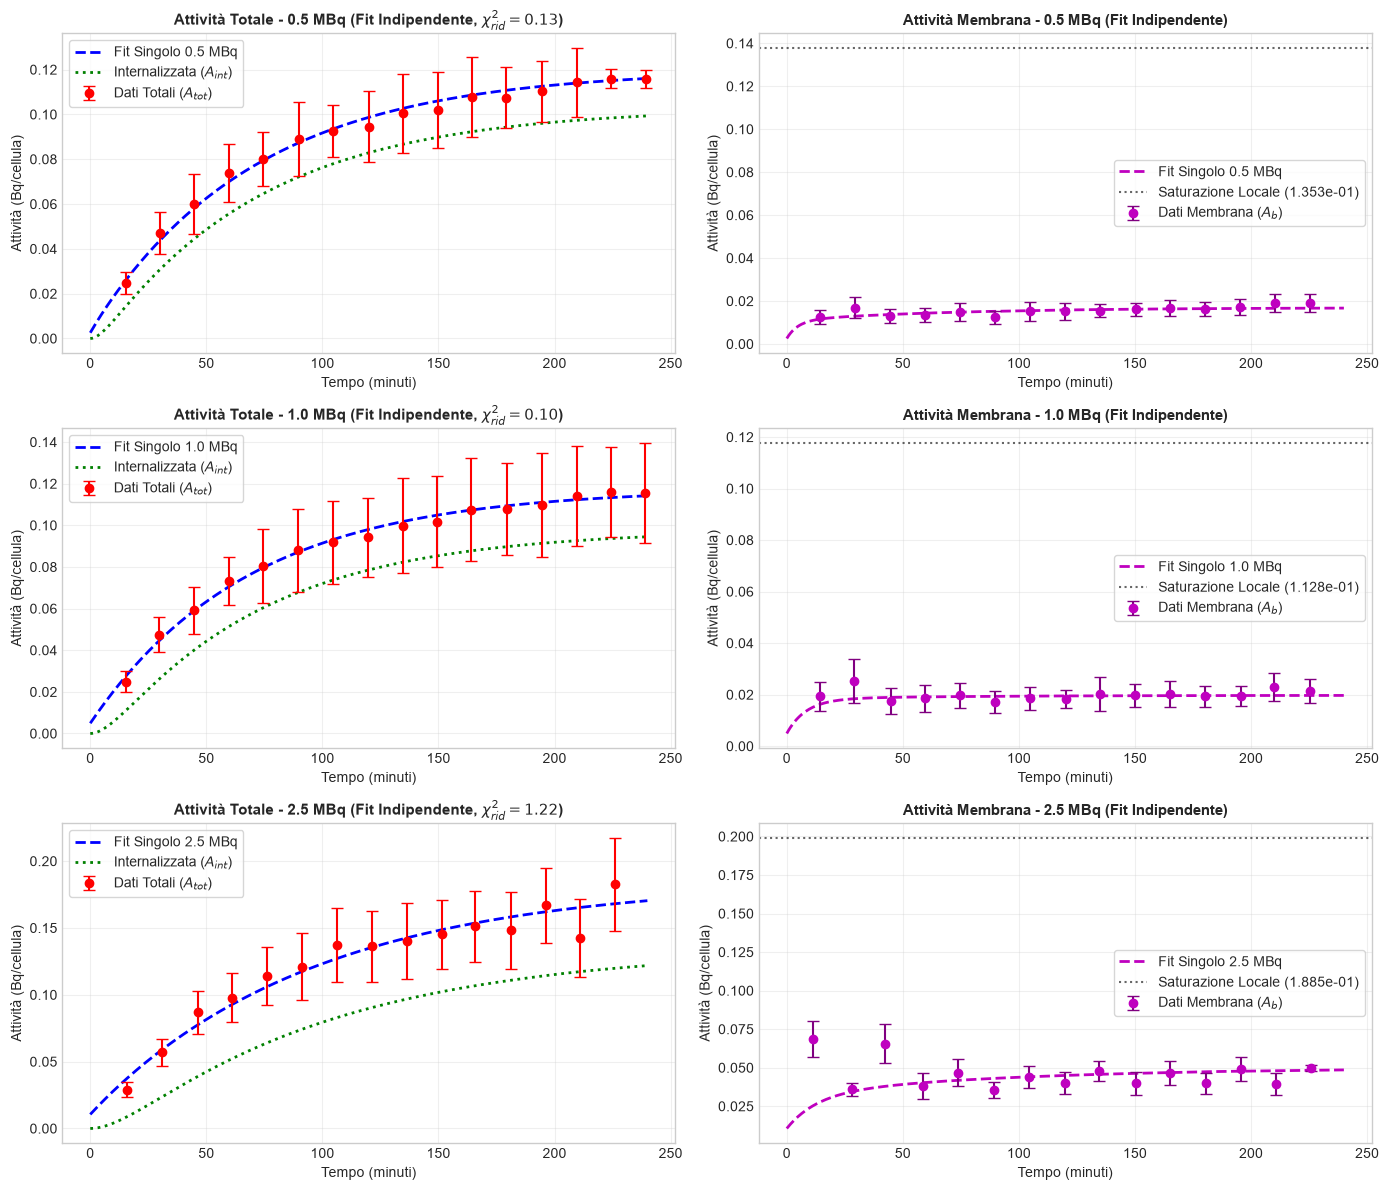

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# =============================================================================
# FUNZIONE ROBUSTA DI CARICAMENTO E FILTRAGGIO (0 - 4 ORE)
# =============================================================================
def load_csv_data_4h(file_path):
    """Carica il CSV e mantiene unicamente i punti dell'incubazione (t <= 240 min)."""
    try:
        df = pd.read_csv(file_path, header=None, sep=None, engine='python')
    except Exception:
        df = pd.read_csv(file_path, header=None)
        
    for col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')
        
    df = df.dropna()
    if df.empty:
        raise ValueError(f"ERRORE: Impossibile leggere dati da '{file_path}'.")
        
    t_min = df.iloc[:, 0].values.astype(float)
    mask = t_min <= 240.0
    
    if df.shape[1] == 1:
        return t_min[mask]
    else:
        y_val = df.iloc[:, 1].values.astype(float)
        return t_min[mask], y_val[mask]

# =============================================================================
# 1. CARICAMENTO DEI DATASET MULTI-CONCENTRAZIONE
# =============================================================================
dataset_info = [
    {
        'label': '0.5 MBq', 'A0': 500.0,
        'tot_val': 'cell_activity_05MBq_values.csv', 'tot_err': 'cell_activity_05MBq_errors.csv',
        'mem_val': 'membrane_activity_05MBq_values.csv', 'mem_err': 'membrane_activity_05MBq_errors.csv'
    },
    {
        'label': '1.0 MBq', 'A0': 1000.0,
        'tot_val': 'cell_activity_1MBq_values.csv', 'tot_err': 'cell_activity_1MBq_errors.csv',
        'mem_val': 'membrane_activity_1MBq_values.csv', 'mem_err': 'membrane_activity_1MBq_errors.csv'
    },
    {
        'label': '2.5 MBq', 'A0': 2500.0,
        'tot_val': 'cell_activity_25MBq_values.csv', 'tot_err': 'cell_activity_25MBq_errors.csv',
        'mem_val': 'membrane_activity_25MBq_values.csv', 'mem_err': 'membrane_activity_25MBq_errors.csv'
    }
]

exp_data = []

for ds in dataset_info:
    t_min_tot, y_tot_exp = load_csv_data_4h(ds['tot_val'])
    res_tot_err          = load_csv_data_4h(ds['tot_err'])
    err_tot_raw          = res_tot_err[1] if isinstance(res_tot_err, tuple) else res_tot_err
    
    if len(err_tot_raw) == len(y_tot_exp) and np.max(err_tot_raw) > np.max(y_tot_exp) * 0.5:
        err_tot = np.maximum(np.abs(err_tot_raw - y_tot_exp), 1e-8)
    else:
        err_tot = np.maximum(err_tot_raw, 1e-8)
    
    t_min_mem, y_mem_exp = load_csv_data_4h(ds['mem_val'])
    res_mem_err          = load_csv_data_4h(ds['mem_err'])
    err_mem_raw          = res_mem_err[1] if isinstance(res_mem_err, tuple) else res_mem_err
    
    if len(err_mem_raw) == len(y_mem_exp) and np.max(err_mem_raw) > np.max(y_mem_exp) * 0.5:
        err_mem = np.maximum(np.abs(err_mem_raw - y_mem_exp), 1e-8)
    else:
        err_mem = np.maximum(err_mem_raw, 1e-8)
        
    exp_data.append({
        'label': ds['label'], 'A0': ds['A0'],
        't_min_tot': t_min_tot, 't_exp_tot': t_min_tot / 60.0, 'y_tot_exp': y_tot_exp, 'err_tot': err_tot,
        't_min_mem': t_min_mem, 't_exp_mem': t_min_mem / 60.0, 'y_mem_exp': y_mem_exp, 'err_mem': err_mem
    })

lmbda = 0.0

# =============================================================================
# 2. MODELLO ODE E RESIDUI PER SINGOLO DATASET
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """
    Parametri (6): [k0, k1_eff, k2, k3, B_max, k_ns]
    """
    k0, k1_eff, k2, k3, B_max, k_ns = params

    def ode_system(t, y):
        Am, Ab, Aint = y
        occupied_receptors = Ab + Aint
        free_rec = max(0.0, 1.0 - occupied_receptors / B_max) if B_max > 0 else 0.0

        dAm   = - lmbda * Am - k1_eff * Am * free_rec + k0 * Ab
        dAb   =   k1_eff * Am * free_rec - (k0 + k2 + lmbda) * Ab + k3 * Aint
        dAint =   k2 * Ab - (k3 + lmbda) * Aint
        return [dAm, dAb, dAint]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')

    nsb_component = k_ns * A0
    A_mem_pred = sol.y[1] + nsb_component
    A_tot_pred = sol.y[1] + sol.y[2] + nsb_component
    return A_mem_pred, A_tot_pred

def single_dataset_residuals(params, exp):
    """Calcola i residui pesati per un singolo dataset."""
    A0 = exp['A0']
    
    _, pred_tot = solve_ode_system(params, exp['t_exp_tot'], A0)
    weights_tot = np.maximum(exp['err_tot'], 0.02 * exp['y_tot_exp'])
    res_tot = (pred_tot - exp['y_tot_exp']) / weights_tot
    
    pred_mem, _ = solve_ode_system(params, exp['t_exp_mem'], A0)
    weights_mem = np.maximum(exp['err_mem'], 0.02 * exp['y_mem_exp'])
    res_mem = (pred_mem - exp['y_mem_exp']) / weights_mem
    
    return np.concatenate([res_tot, res_mem])

# =============================================================================
# 3. ESECUZIONE DEI FIT SINGOLI
# =============================================================================
p0           = [2.0,  1.0e-4, 1.0,  0.1,  0.04,   1.0e-6]
lower_bounds = [0.01, 1.0e-6, 0.01, 0.0,  0.001,  0.0]
upper_bounds = [20.0, 1.0e-2, 10.0, 5.0,  0.5,    1.0e-3]

single_fit_results = []

for exp in exp_data:
    res_fit = least_squares(
        single_dataset_residuals, 
        p0, 
        bounds=(lower_bounds, upper_bounds),
        args=(exp,),
        method='trf',
        x_scale='jac',
        loss='soft_l1',
        f_scale=1.0
    )
    
    # Statistica del fit singolo
    N_points = len(res_fit.fun)
    p_num = len(res_fit.x)
    dof = N_points - p_num
    chi2 = np.sum(res_fit.fun**2)
    chi2_red = chi2 / dof if dof > 0 else 1.0

    J = res_fit.jac
    try:
        cov = np.linalg.pinv(J.T @ J) * chi2_red
        errors = np.sqrt(np.diagonal(cov))
    except Exception:
        errors = np.full(p_num, np.nan)
        
    single_fit_results.append({
        'exp': exp,
        'params': res_fit.x,
        'errors': errors,
        'chi2': chi2,
        'chi2_red': chi2_red,
        'dof': dof,
        'N': N_points
    })

# =============================================================================
# 4. REPORT COMPARATIVO DEI RISULTATI
# =============================================================================
param_names = ['k0 (koff, h^-1)', 'k1_eff (kon, h^-1)', 'k2 (kint, h^-1)', 
               'k3 (kout, h^-1)', 'B_max (Bq/cell)', 'k_ns (NSB coefficient)']

print("=============================================================================================")
print("                           RISULTATI FIT SINGOLI PER CONCENTRAZIONE                          ")
print("=============================================================================================")
header_str = f"{'Parametro':<24}"
for res in single_fit_results:
    header_str += f" | {res['exp']['label']:<28}"
print(header_str)
print("-" * 93)

for i, p_name in enumerate(param_names):
    row_str = f"{p_name:<24}"
    for res in single_fit_results:
        val = res['params'][i]
        err = res['errors'][i]
        row_str += f" | {val:.4e} ± {err:.4e}"
    print(row_str)

print("-" * 93)
chi2_str = f"{'Chi2 Ridotto (dof)':<24}"
for res in single_fit_results:
    chi2_str += f" | {res['chi2_red']:.4f} (dof={res['dof']})"
print(chi2_str)
print("=============================================================================================\n")

# =============================================================================
# 5. GRAFICI DEI FIT INDIPENDENTI
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, res in enumerate(single_fit_results):
    exp = res['exp']
    params = res['params']
    A0 = exp['A0']
    
    t_smooth_h = np.linspace(0, 4.0, 300)
    pred_mem_smooth, pred_tot_smooth = solve_ode_system(params, t_smooth_h, A0)
    pred_int_smooth = pred_tot_smooth - pred_mem_smooth
    t_smooth_min = t_smooth_h * 60.0

    # Colonna 1: Totale e Internalizzata
    ax_tot = axes[idx, 0]
    ax_tot.errorbar(exp['t_min_tot'], exp['y_tot_exp'], yerr=exp['err_tot'], 
                    fmt='ro', ecolor='red', capsize=4, label='Dati Totali ($A_{tot}$)', zorder=5)
    ax_tot.plot(t_smooth_min, pred_tot_smooth, 'b--', linewidth=2, label=f'Fit Singolo {exp["label"]}')
    ax_tot.plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Internalizzata ($A_{int}$)')
    ax_tot.set_title(f"Attività Totale - {exp['label']} (Fit Indipendente, $\chi^2_{{rid}}={res['chi2_red']:.2f}$)", fontsize=11, fontweight='bold')
    ax_tot.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_tot.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_tot.grid(True, alpha=0.3)
    ax_tot.legend(frameon=True)

    # Colonna 2: Membrana
    ax_mem = axes[idx, 1]
    ax_mem.errorbar(exp['t_min_mem'], exp['y_mem_exp'], yerr=exp['err_mem'], 
                    fmt='mo', ecolor='purple', capsize=4, label='Dati Membrana ($A_b$)', zorder=5)
    ax_mem.plot(t_smooth_min, pred_mem_smooth, 'm--', linewidth=2, label=f'Fit Singolo {exp["label"]}')
    
    B_max_val = params[4]
    k_ns_val = params[5]
    ax_mem.axhline(y=B_max_val + k_ns_val * A0, color='black', linestyle=':', alpha=0.6, label=f'Saturazione Locale ({B_max_val:.3e})')
    ax_mem.set_title(f"Attività Membrana - {exp['label']} (Fit Indipendente)", fontsize=11, fontweight='bold')
    ax_mem.set_xlabel('Tempo (minuti)', fontsize=10)
    ax_mem.set_ylabel('Attività (Bq/cellula)', fontsize=10)
    ax_mem.grid(True, alpha=0.3)
    ax_mem.legend(frameon=True)

plt.tight_layout()
plt.show()
